PHASE 2- ARIMA AND ETS

ARIMA model is comprised of three parts, first one is AR which stands for autoregressive and P value is linked to it which basically tells how many past values or time stamps should the model consider before making some prediction, second part is I which stands for integration and is linked to d value which means diffrencing, it makes the data stationary so that ARMA model can be used on it and the third part is MA which stands for moving average and is linked to q value which means how many past error values should the model consider before making the future prediction.

DATA LOADING AND PRE PROCESSING &
TRAIN/TEST SPLIT

<>:7: SyntaxWarning: invalid escape sequence '\D'
<>:7: SyntaxWarning: invalid escape sequence '\D'
C:\Users\tavis\AppData\Local\Temp\ipykernel_19316\3304809766.py:7: SyntaxWarning: invalid escape sequence '\D'
  df=pd.read_csv("C:/Users/tavis\Downloads/archive (1)/Sample - Superstore.csv", encoding='ISO-8859-1')


C:\Users\tavis\Downloads\archive (1)
month
1      94924.8356
2      59751.2514
3     205005.4888
4     137762.1286
5     155028.8117
6     152718.6793
7     147238.0970
8     159044.0630
9     307649.9457
10    200322.9847
11    352461.0710
12    325293.5035
Name: Sales, dtype: float64
Order Date
2014-01-31     14236.8950
2014-02-28      4519.8920
2014-03-31     55691.0090
2014-04-30     28295.3450
2014-05-31     23648.2870
2014-06-30     34595.1276
2014-07-31     33946.3930
2014-08-31     27909.4685
2014-09-30     81777.3508
2014-10-31     31453.3930
2014-11-30     78628.7167
2014-12-31     69545.6205
2015-01-31     18174.0756
2015-02-28     11951.4110
2015-03-31     38726.2520
2015-04-30     34195.2085
2015-05-31     30131.6865
2015-06-30     24797.2920
2015-07-31     28765.3250
2015-08-31     36898.3322
2015-09-30     64595.9180
2015-10-31     31404.9235
2015-11-30     75972.5635
2015-12-31     74919.5212
2016-01-31     18542.4910
2016-02-29     22978.8150
2016-03-31     51715.8750


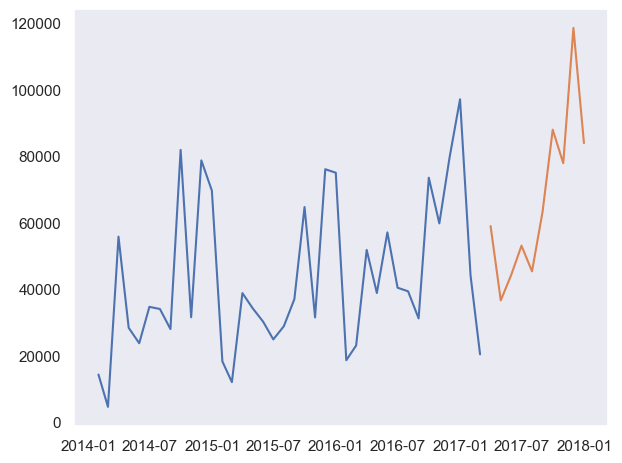

In [14]:

import zipfile

with zipfile.ZipFile(r'C:/Users/tavis/Downloads/archive (1).zip', 'r') as zip_ref:
    zip_ref.extractall(r'C:/Users/tavis/Downloads/archive (1)')
    %cd C:\Users\tavis\Downloads\archive (1)
import pandas as pd
df=pd.read_csv("C:/Users/tavis\Downloads/archive (1)/Sample - Superstore.csv", encoding='ISO-8859-1')

df
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['month']=df['Order Date'].dt.month
df
results=df.groupby('month')['Sales'].sum()
print(results)

monthly=df.resample('ME', on='Order Date')['Sales'].sum()
print(monthly)


from matplotlib import pyplot as plt

split = int(len(monthly) * 0.8)
train = monthly[:split]
plt.plot(train)
test = monthly[split:]
plt.plot(test)
plt.tight_layout()
plt.grid()
plt.show()

In [15]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np
def evaluate(actual, predicted):
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mae = mean_absolute_error(actual, predicted)
    mape = np.mean(np.abs((actual-predicted)/actual))*100
    return {'RMSE':round(rmse,2), 'MAE':round(mae,2), 'MAPE':round(mape,2)}

ARIMA MODEL

In [16]:
from pmdarima import auto_arima

model_arima = auto_arima(
    train,
    seasonal=True,
    m=12,              
    stepwise=True,
    suppress_warnings=True,
    information_criterion='aic',
    max_p=3, max_q=3,  
    max_P=2, max_Q=2,
    D=0,              
    error_action='ignore'
)

print(model_arima.summary())
forecast_arima = model_arima.predict(n_periods=len(test))

                                        SARIMAX Results                                        
Dep. Variable:                                       y   No. Observations:                   38
Model:             SARIMAX(0, 0, 1)x(0, 0, [1, 2], 12)   Log Likelihood                -427.092
Date:                                 Tue, 05 May 2026   AIC                            864.183
Time:                                         22:13:55   BIC                            872.371
Sample:                                     01-31-2014   HQIC                           867.096
                                          - 02-28-2017                                         
Covariance Type:                                   opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept   4.353e+04   9698.121      4.488      0.000    2.45e+04    6.25

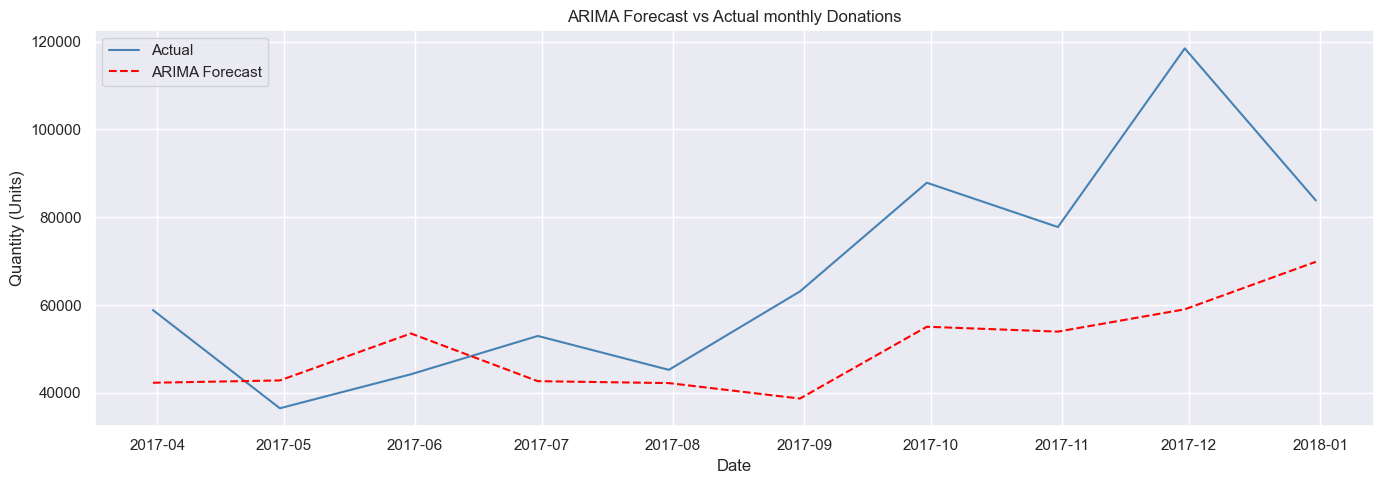

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme()

fig, ax = plt.subplots(figsize=(14, 5))

# "actual test" = the real donation values from your held-out test period
ax.plot(test.index, test.values, color='steelblue', linewidth=1.5, label='Actual')

# "ARIMA forecast" = what your model predicted for those same weeks
ax.plot(test.index, forecast_arima, color='red', linestyle='--', linewidth=1.5, label='ARIMA Forecast')

ax.set_title('ARIMA Forecast vs Actual monthly Donations')
ax.set_xlabel('Date')
ax.set_ylabel('Quantity (Units)')
ax.legend()
plt.tight_layout()

plt.show()

In [18]:
arima_metrics = evaluate(test.values, forecast_arima)
results['ARIMA'] = arima_metrics
print(results)

month
1                                               94924.8356
2                                               59751.2514
3                                              205005.4888
4                                              137762.1286
5                                              155028.8117
6                                              152718.6793
7                                               147238.097
8                                               159044.063
9                                              307649.9457
10                                             200322.9847
11                                              352461.071
12                                             325293.5035
ARIMA    {'RMSE': 25445.61, 'MAE': 19981.86, 'MAPE': 26...
Name: Sales, dtype: object


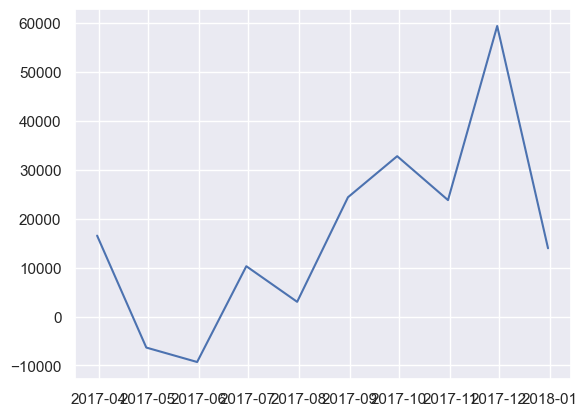

In [19]:
residuals = test.values - forecast_arima
plt.plot(residuals)
plt.tight_layout
plt.show()



ETS MODEL

In [20]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing
model_ets = ExponentialSmoothing(train, trend='add', seasonal='add', seasonal_periods=12).fit()
forecast_ets = model_ets.forecast(len(test))
ets_metrics = evaluate(test.values, forecast_ets.values)
results['ETS'] = ets_metrics
print(results)

month
1                                               94924.8356
2                                               59751.2514
3                                              205005.4888
4                                              137762.1286
5                                              155028.8117
6                                              152718.6793
7                                               147238.097
8                                               159044.063
9                                              307649.9457
10                                             200322.9847
11                                              352461.071
12                                             325293.5035
ARIMA    {'RMSE': 25445.61, 'MAE': 19981.86, 'MAPE': 26...
ETS      {'RMSE': 12396.26, 'MAE': 11175.29, 'MAPE': 18...
Name: Sales, dtype: object


MODEL COMPARISON

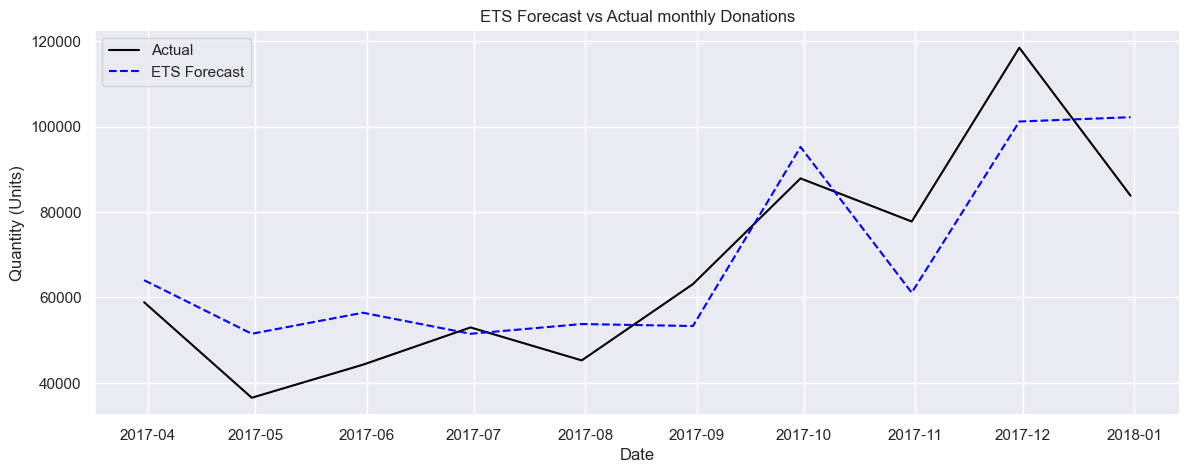

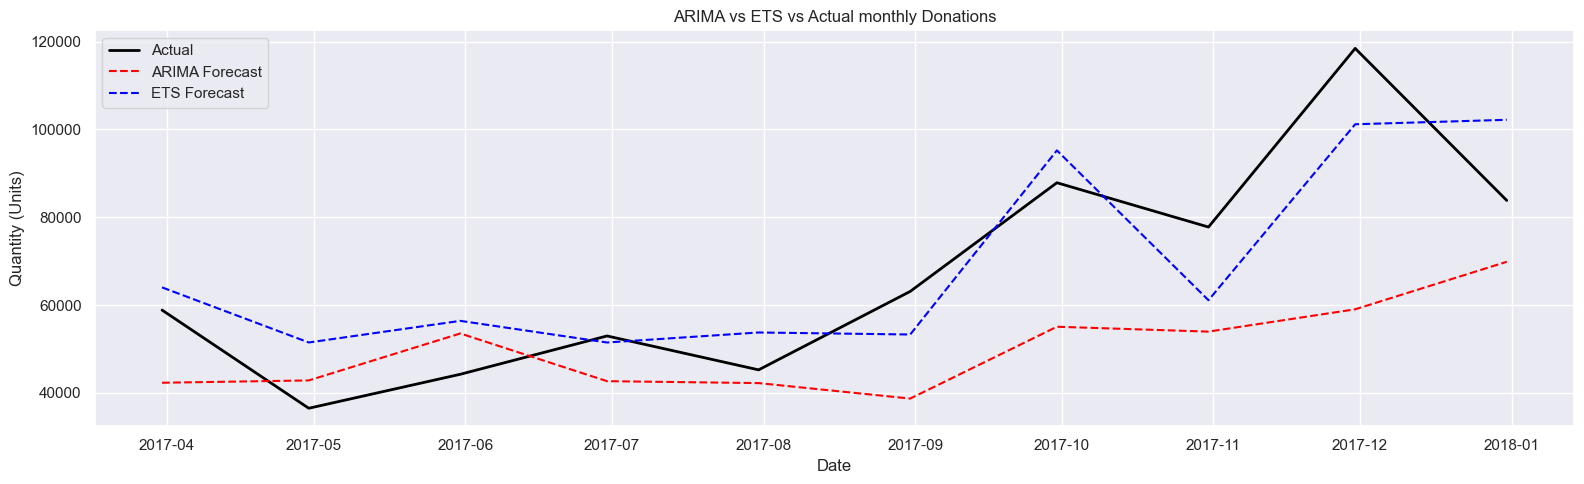

In [21]:

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme()

# --- fig7: ETS forecast vs actual ---
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(test.index, test.values, color='black', linewidth=1.5, label='Actual')
ax.plot(test.index, forecast_ets.values, color='blue', linestyle='--', linewidth=1.5, label='ETS Forecast')

ax.set_title('ETS Forecast vs Actual monthly Donations')
ax.set_xlabel('Date')
ax.set_ylabel('Quantity (Units)')
ax.legend()

plt.show()

# --- fig8: ARIMA vs ETS vs Actual ---
fig, ax = plt.subplots(figsize=(16, 5))

ax.plot(test.index, test.values, color='black', linewidth=2, label='Actual')
ax.plot(test.index, forecast_arima, color='red', linestyle='--', linewidth=1.5, label='ARIMA Forecast')
ax.plot(test.index, forecast_ets.values, color='blue', linestyle='--', linewidth=1.5, label='ETS Forecast')

ax.set_title('ARIMA vs ETS vs Actual monthly Donations')
ax.set_xlabel('Date')
ax.set_ylabel('Quantity (Units)')
ax.legend()
plt.tight_layout()

plt.show()

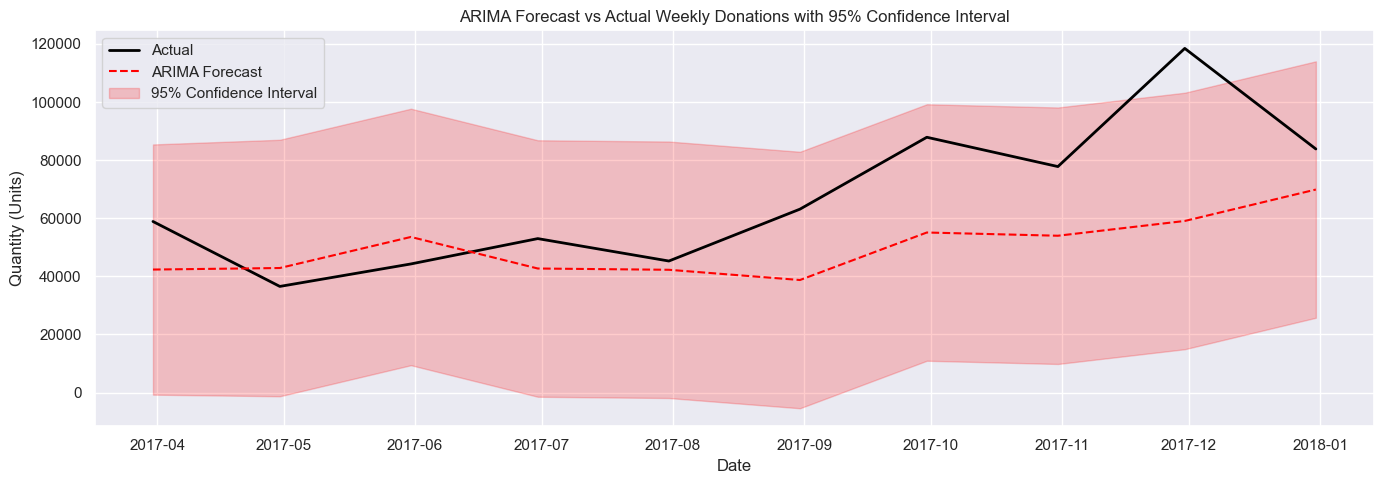

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme()

# Get forecast with confidence intervals
forecast_ci, conf_int = model_arima.predict(n_periods=len(test), return_conf_int=True)

fig, ax = plt.subplots(figsize=(14, 5))

# Actual test values
ax.plot(test.index, test.values, color='black', linewidth=2, label='Actual')

# ARIMA forecast line
ax.plot(test.index, forecast_ci, color='red', linestyle='--', linewidth=1.5, label='ARIMA Forecast')

# Confidence band (shaded region)
ax.fill_between(test.index, conf_int[:, 0], conf_int[:, 1],
                alpha=0.2, color='red', label='95% Confidence Interval')

ax.set_title('ARIMA Forecast vs Actual Weekly Donations with 95% Confidence Interval')
ax.set_xlabel('Date')
ax.set_ylabel('Quantity (Units)')
ax.legend()
plt.tight_layout()
plt.show()


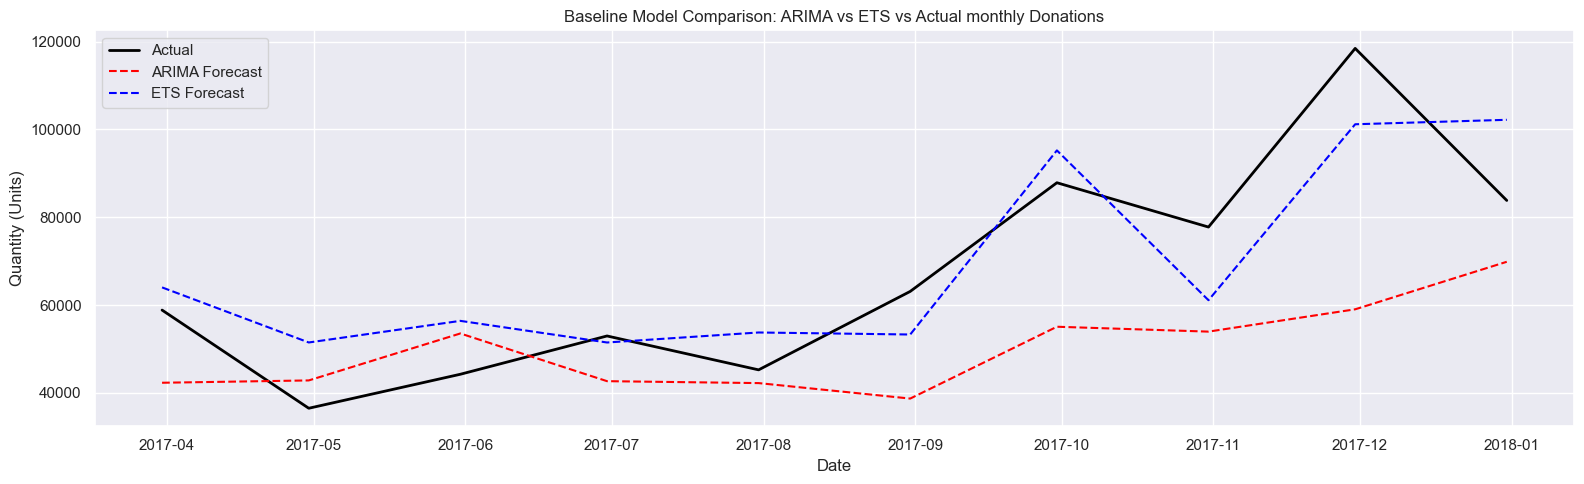

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme()

fig, ax = plt.subplots(figsize=(16, 5))

ax.plot(test.index, test.values, color='black', linewidth=2, label='Actual')
ax.plot(test.index, forecast_arima, color='red', linestyle='--', linewidth=1.5, label='ARIMA Forecast')
ax.plot(test.index, forecast_ets.values, color='blue', linestyle='--', linewidth=1.5, label='ETS Forecast')

ax.set_title('Baseline Model Comparison: ARIMA vs ETS vs Actual monthly Donations')
ax.set_xlabel('Date')
ax.set_ylabel('Quantity (Units)')
ax.legend()
plt.tight_layout()

plt.show()

In [24]:
# Run this to see your model's AIC score and what it selected
print("Model order selected:", model_arima.order)
print("Seasonal order selected:", model_arima.seasonal_order)
print("AIC score:", round(model_arima.aic(), 2))

# Write in a markdown cell below:
# AIC (Akaike Information Criterion) penalises model complexity.
# auto_arima tries many p,d,q combinations and picks the one with
# the lowest AIC — meaning best fit without overfitting.

Model order selected: (0, 0, 1)
Seasonal order selected: (0, 0, 2, 12)
AIC score: 864.18


In [25]:
# Check if seasonal parameters were selected
order = model_arima.order          # (p, d, q)
seasonal_order = model_arima.seasonal_order  # (P, D, Q, m)

print(f"ARIMA order: p={order[0]}, d={order[1]}, q={order[2]}")
print(f"Seasonal order: P={seasonal_order[0]}, D={seasonal_order[1]}, Q={seasonal_order[2]}, m={seasonal_order[3]}")

if any(v > 0 for v in seasonal_order[:3]):
    print("→ Model is SARIMA (seasonal parameters were selected)")
else:
    print("→ Model is plain ARIMA (no seasonal component selected)")

ARIMA order: p=0, d=0, q=1
Seasonal order: P=0, D=0, Q=2, m=12
→ Model is SARIMA (seasonal parameters were selected)
